In [22]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(os.path.join(project_root, 'src'))
%load_ext autoreload
%autoreload 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import pandas as pd
from src.data_processing import EDAPipeline, EDAConfig

In [24]:
df=pd.read_csv('../data/raw/data.csv')
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


2026-05-30 11:24:18,360 - INFO - EDAPipeline initialized. Output directory: eda_outputs\eda_run_20260530_112418
2026-05-30 11:24:18,417 - INFO - ✅ Data loaded: 95,662 rows × 16 columns
2026-05-30 11:24:18,419 - INFO -  Starting EDA Pipeline...
2026-05-30 11:24:19,979 - INFO -  Generating visualizations...
2026-05-30 11:24:20,242 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 11:24:20,427 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


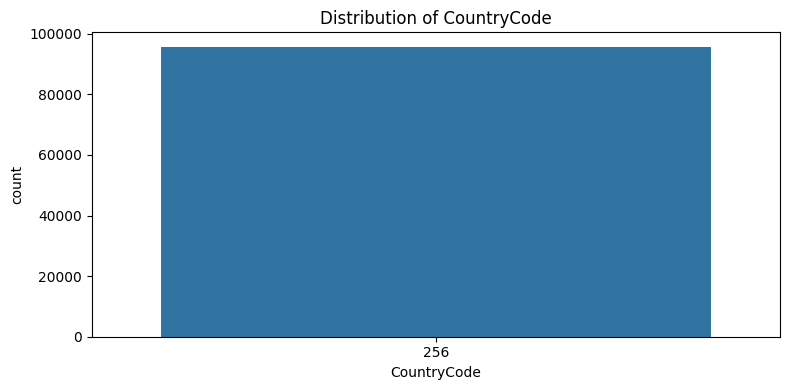

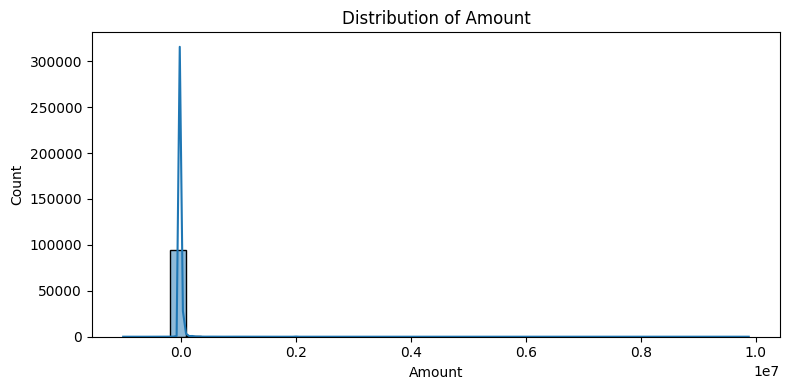

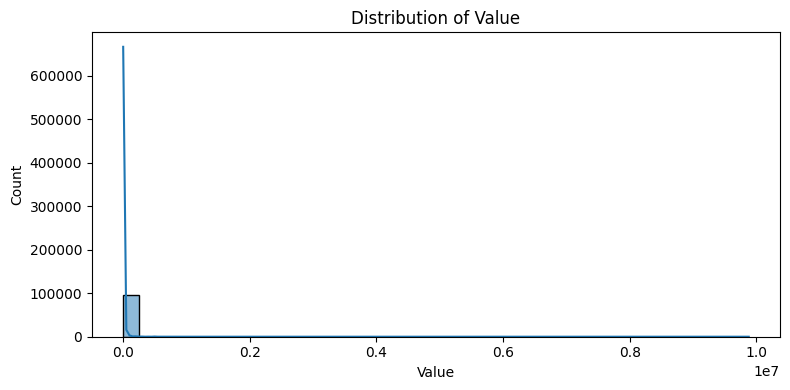

2026-05-30 11:24:25,010 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 11:24:25,195 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


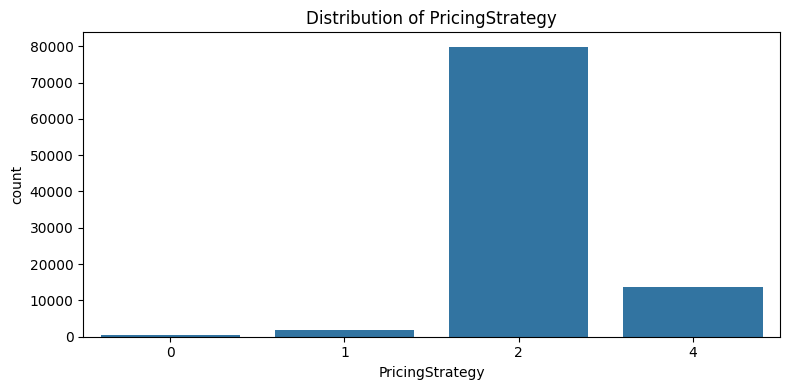

2026-05-30 11:24:26,196 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 11:24:26,416 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


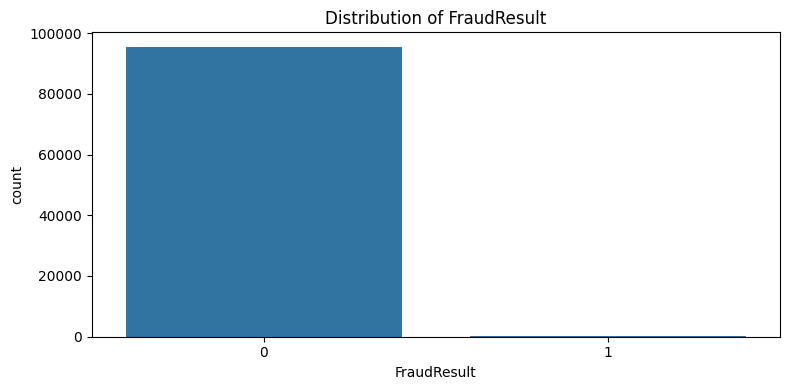

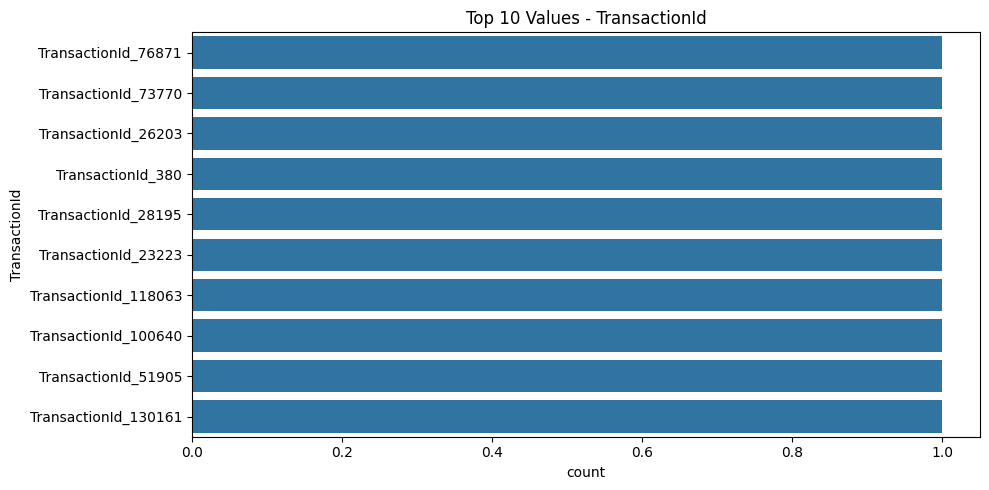

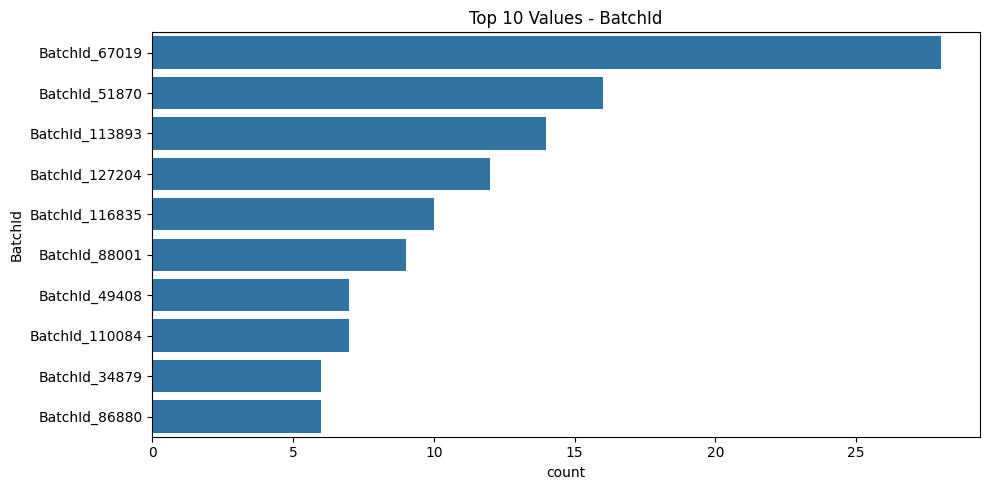

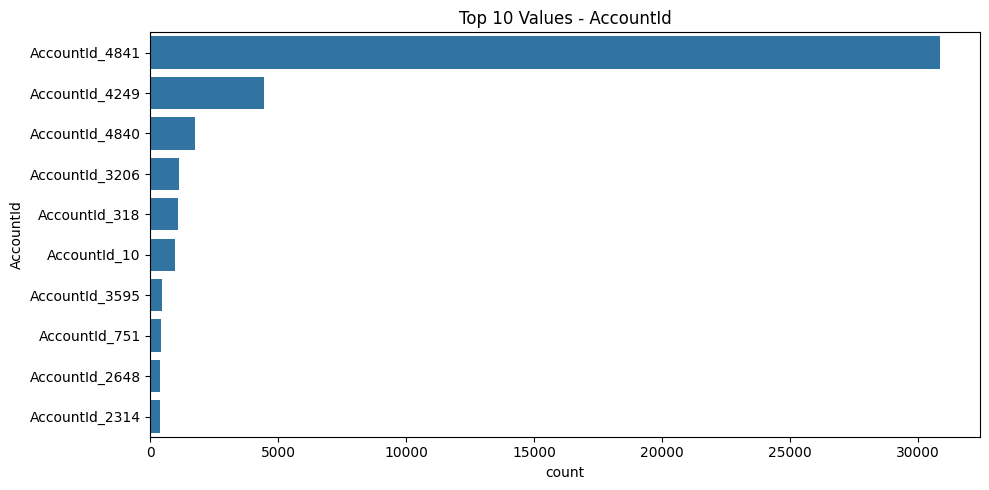

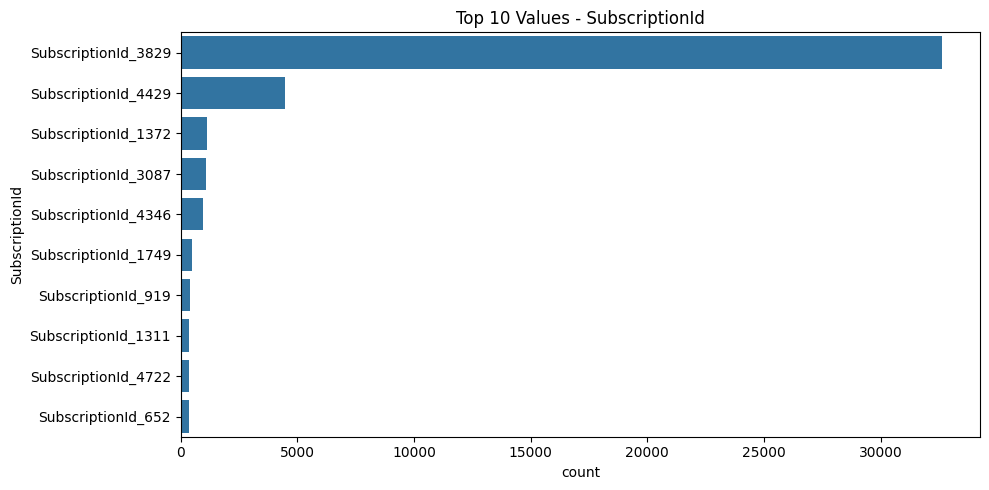

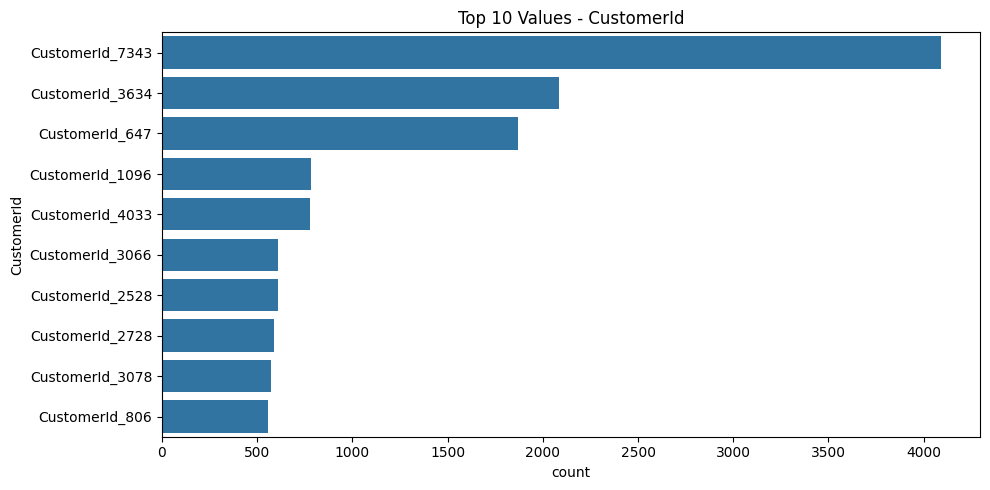

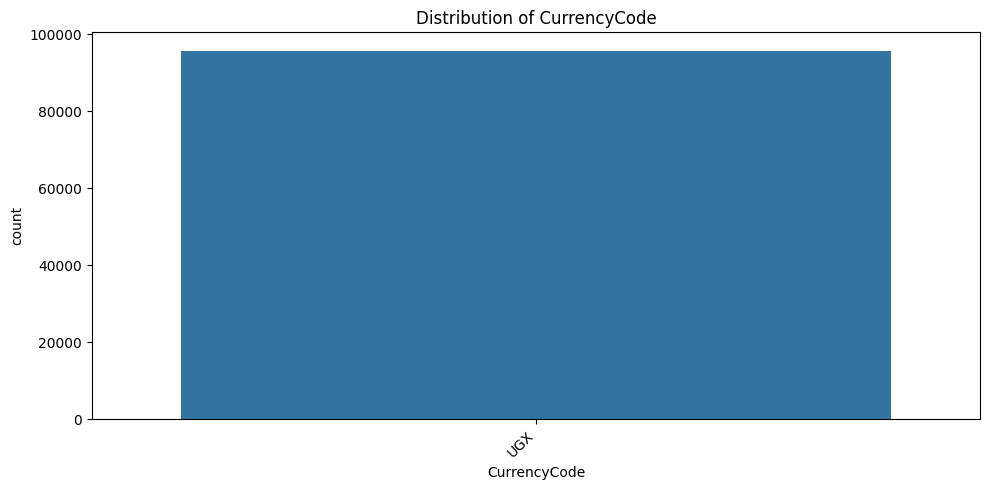

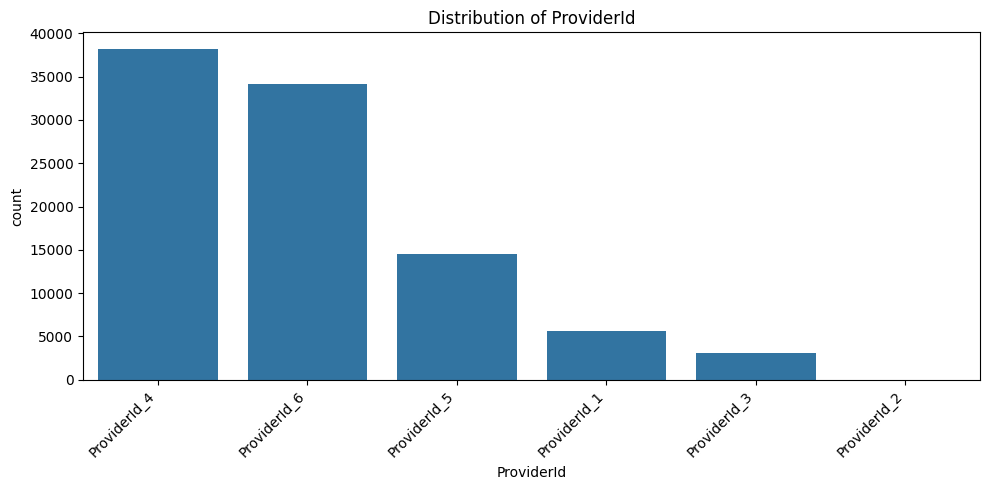

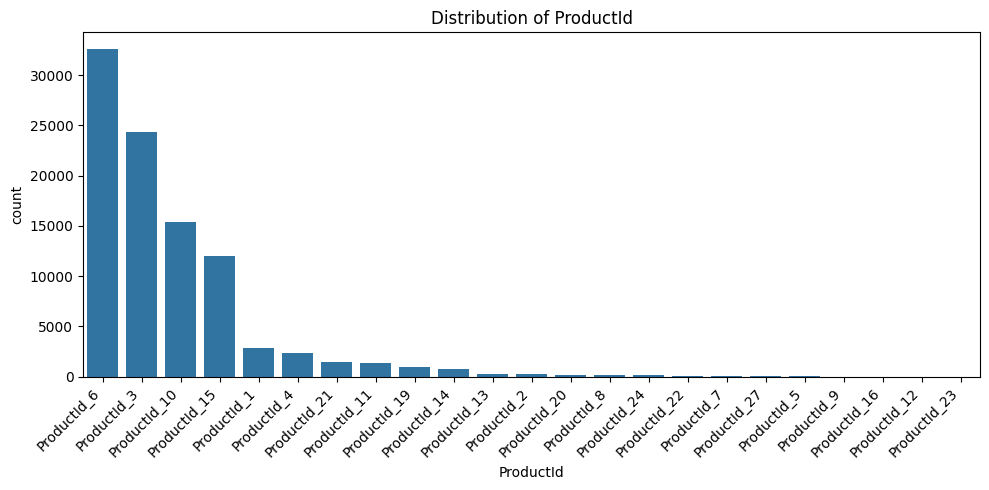

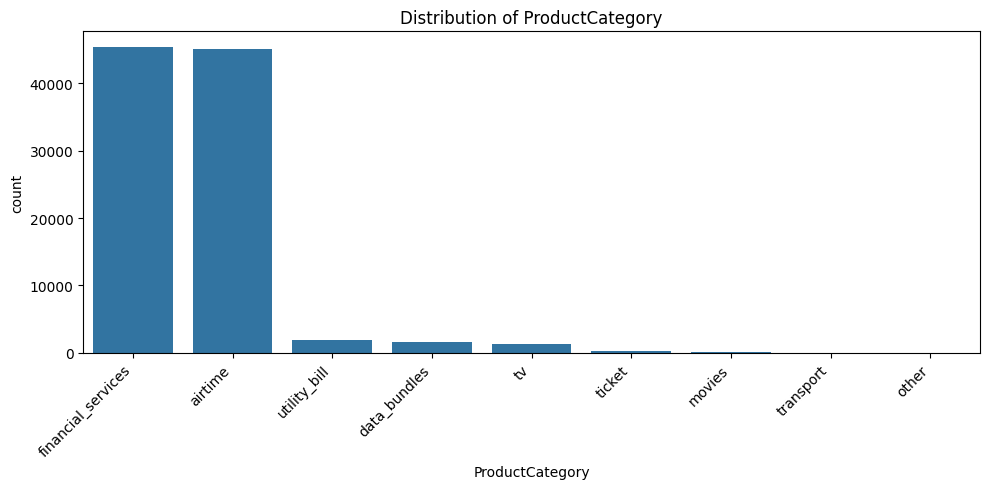

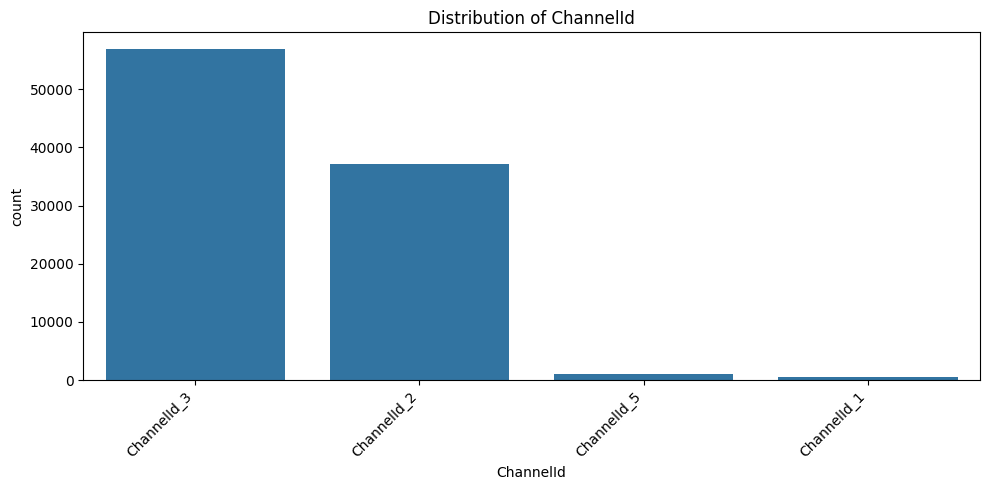

2026-05-30 11:24:42,246 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 11:24:42,320 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


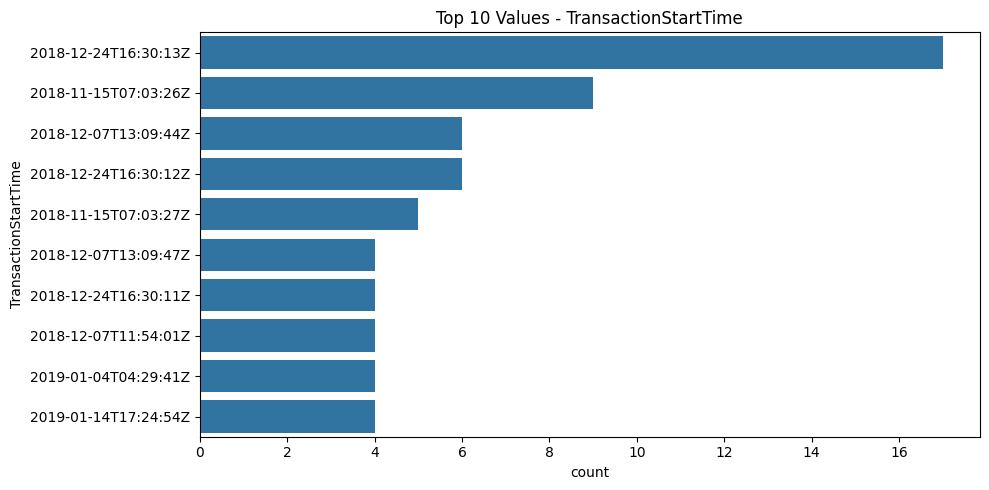

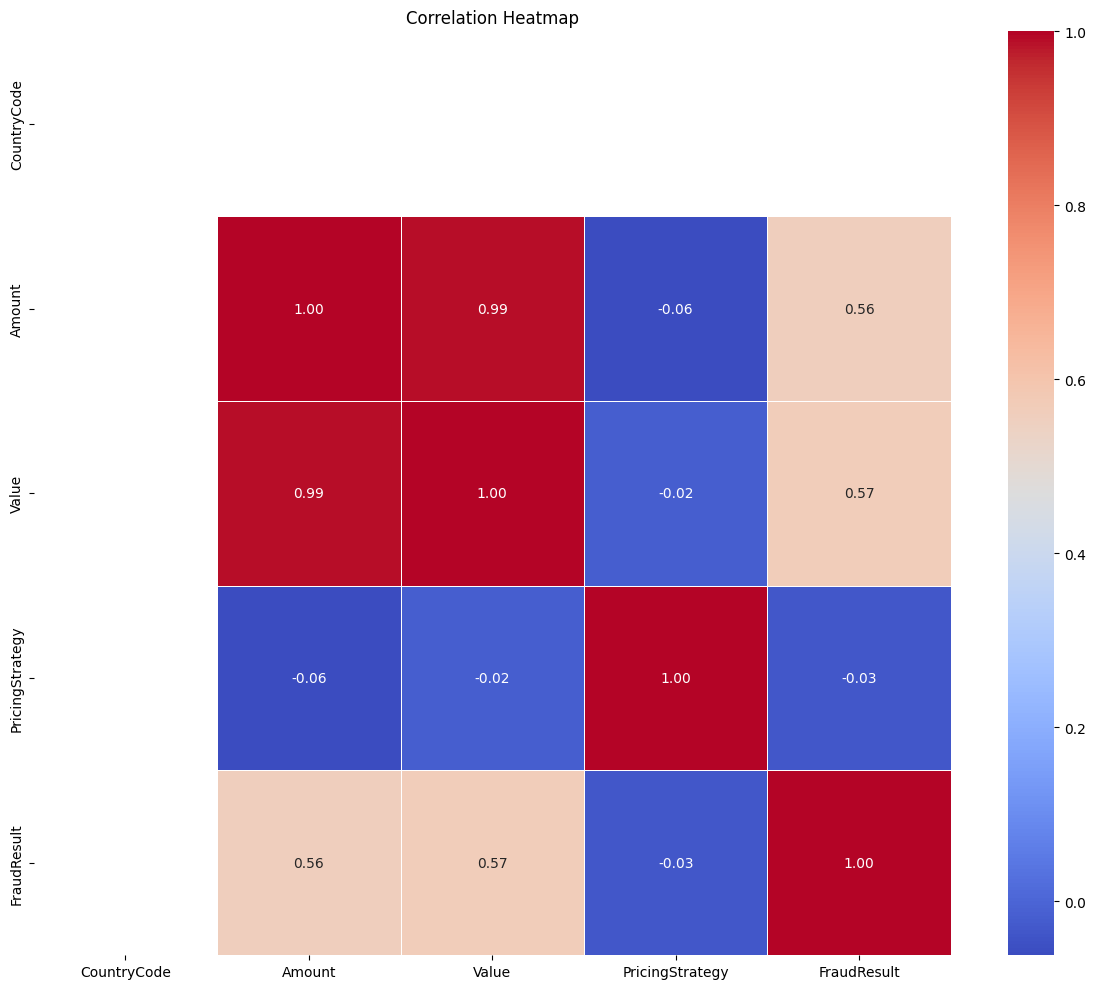

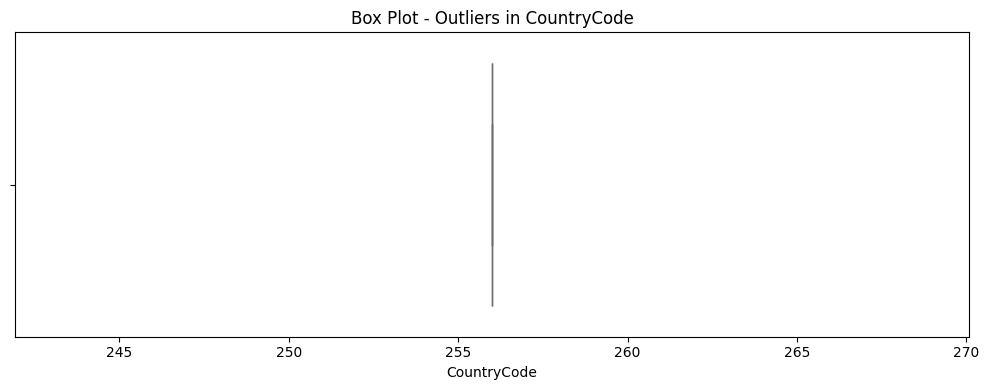

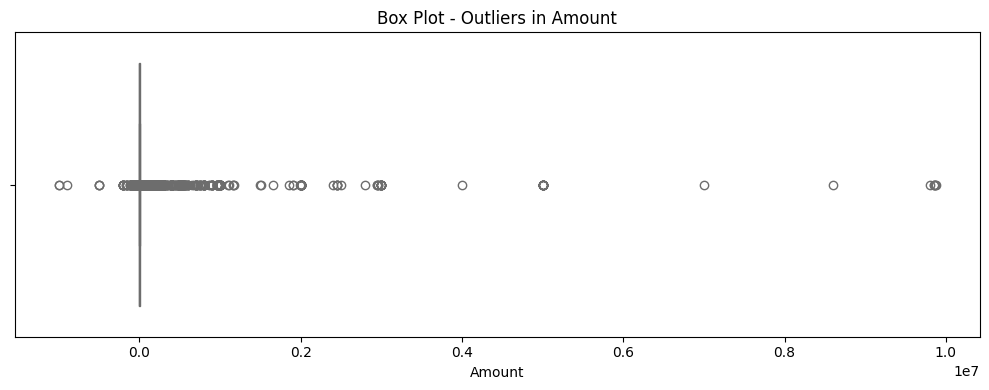

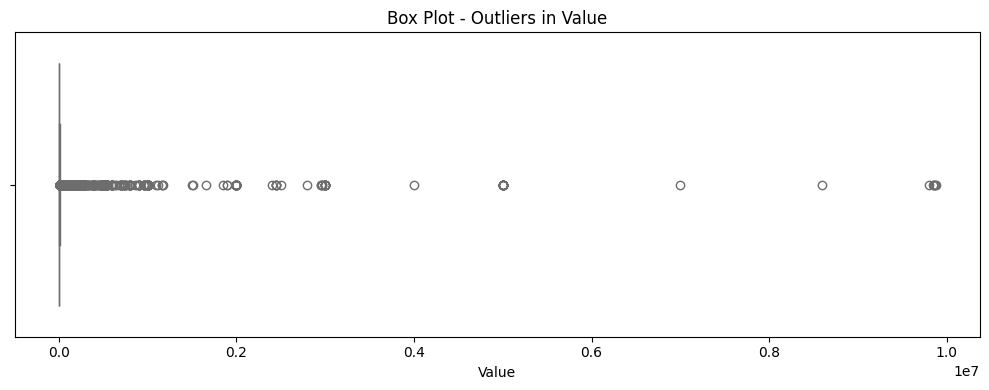

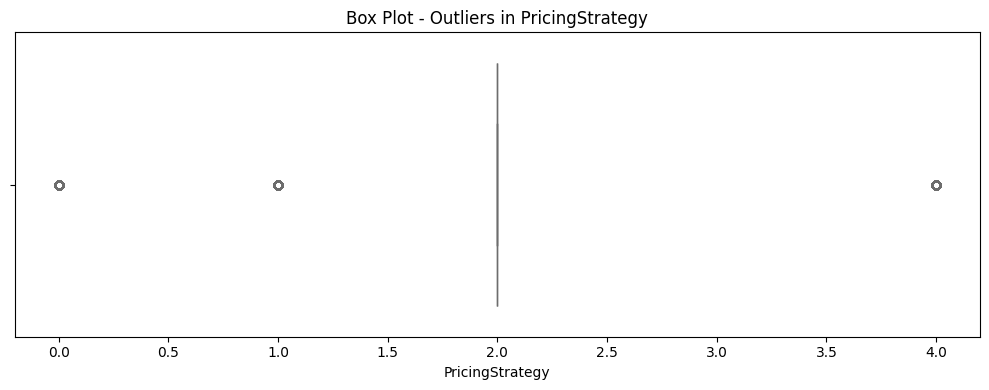

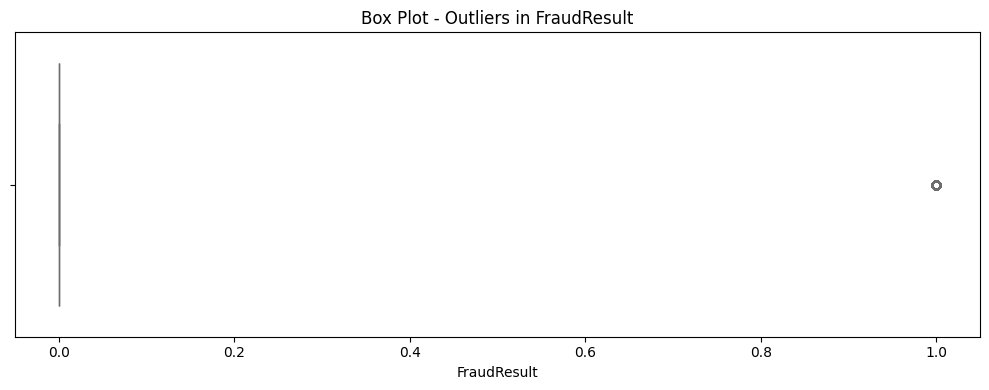

2026-05-30 11:24:49,801 - INFO - Summary report saved: eda_outputs\eda_run_20260530_112418\eda_summary_report.txt
2026-05-30 11:24:49,801 - INFO -  Configuration saved: eda_outputs\eda_run_20260530_112418\config.json
2026-05-30 11:24:49,801 - INFO -  EDA Pipeline completed successfully!


EDA Completed! Check the output folder.


In [25]:
config = EDAConfig(
        sample_size=None,  
        save_plots=True,
        include_plots=True
    )
    
pipeline = EDAPipeline(config)
    
results = (pipeline
               .load_data(df)
               .run())
    
print("EDA Completed! Check the output folder.")

### EDA Report: Credit Risk Modeling Dataset

**Generated on:** 30 May 2026  
**Dataset Size:** 95,662 rows × 16 columns  
**Memory Usage:** 74.51 MB  
**Missing Values:** None (Clean dataset)


#### Executive Summary

This EDA reveals a highly skewed financial dataset dominated by **extreme outliers** in monetary variables (`Amount` and `Value`). The target variable `FraudResult` is highly imbalanced, which is typical in fraud detection problems. Several features show characteristics that will require careful preprocessing before modeling.


#### Top 5 Key Insights

 1. **Extreme Right-Skewness in Monetary Features**
- `Amount` and `Value` exhibit extremely high positive skewness (**51.10** and **51.29** respectively) and very high kurtosis (> 3360).
- This indicates a heavy concentration of small/medium transactions with a few extremely large outliers.
- **Recommendation:** Strong transformation (e.g., log, box-cox, or robust scalers) is necessary.

 2. **High Outlier Prevalence**
- `Amount`: **25.55%** outliers
- `PricingStrategy`: **16.53%** outliers  
- `Value`: **9.43%** outliers
- These high outlier percentages confirm the heavy-tailed nature of the data.
- **Recommendation:** Investigate whether these outliers are legitimate high-value transactions or data errors. Consider winsorization or robust modeling techniques.

 3. **Severe Class Imbalance in FraudResult**
- Mean of `FraudResult` = **0.002** (only ~0.2% fraudulent cases).
- Very high skewness (**22.20**) and kurtosis (**490.69**).
- **Recommendation:** Use appropriate techniques for imbalanced classification (SMOTE, class weights, undersampling, or anomaly detection approaches).

 4. **Constant Feature - CountryCode**
- `CountryCode` is constant, has zero variance (mean = median = 256.0, std = 0).
- This feature provides **no predictive value**.
- **Recommendation:** Drop this column during preprocessing.

 5. **Strong Correlation Between Amount and Value**
- `Amount` and `Value` show high correlation.
- This suggests they carry very similar information (possibly `Value` is derived from or closely related to `Amount`).
- **Recommendation:** Check for multicollinearity. Consider keeping only one of them or creating new derived features.



#### Summary Statistics (Numeric Features)

| Feature            | Mean         | Median   | Std Dev       | Skewness   | Kurtosis    | Insight                          |
|--------------------|--------------|----------|---------------|------------|-------------|----------------------------------|
| CountryCode        | 256.00       | 256.0    | 0.00          | 0.00       | 0.00        | Symmetric                        |
| Amount             | 6,717.85     | 1,000.0  | 123,306.80    | 51.10      | 3,363.13    | Highly right-skewed + Leptokurtic |
| Value              | 9,900.58     | 1,000.0  | 123,122.09    | 51.29      | 3,378.07    | Highly right-skewed + Leptokurtic |
| PricingStrategy    | 2.26         | 2.0      | 0.73          | 1.66       | 2.09        | Highly right-skewed              |
| FraudResult        | 0.002        | 0.0      | 0.045         | 22.20      | 490.69      | Highly right-skewed + Leptokurtic |

---

## Outlier Analysis

- **Highest Outlier Rate:** `Amount` (25.55%)
- **Moderate:** `PricingStrategy` (16.53%)
- **Lower but notable:** `Value` (9.43%)


**Full artifacts** (plots, config, and detailed report) are available in the generated output folder:
`eda_outputs/eda_run_20260530_112418/`

